# COSETTE & MARIUS: Replication Study (Amazon 2014)

This notebook summarizes a replication of Table 5 from Lepage et al. on **Beauty** and **Sports & Outdoors**: pipeline status, test metrics (mean ± std over five seeds), and learning curves from offline files in `reports/`.

**To re-run the full experiment pipeline** (download → … → MARIUS), see **Section 0** below and `jobs/RUN_ORDER.md`.


### Running this notebook

| Goal | WandB required? | What you need |
|------|-----------------|---------------|
| **View bundled results** (tables + curves already in the repo) | **No** | `jupyter` + `pandas` + `matplotlib`; run all cells |
| **Regenerate artifacts after your own replication** | **Yes** (for curves only) | See below |

The notebook itself **never calls the WandB API**. It only reads local files under `reports/results/` and `reports/metrics/`.


### If you replicated the experiments yourself

1. **Train the pipeline** (data → COSETTE → MARIUS) using the scripts in `jobs/` (training logs to WandB if configured in `jobs/env_common.sh`).
2. **Configure WandB for export** (one-time):
   ```bash
   cp jobs/wandb.env.example jobs/wandb.env   # do not commit wandb.env
   # Edit wandb.env: set WANDB_API_KEY and WANDB_ENTITY to your account/team
   ```
   Create an API key at https://wandb.ai/authorize
3. **Export offline artifacts** (from repo root, use the same conda env as training):
   ```bash
   source ~/miniconda3/etc/profile.d/conda.sh && conda activate recsys
   source jobs/wandb.env
   export OUTPUT_ROOT=/path/to/your/outputs   # where *_scores.jsonl live
   python scripts/export_metrics_for_report.py --copy-results --source wandb
   ```
   `--copy-results` reads your score jsonl; `--source wandb` pulls curves from **your** WandB project (`WANDB_PROJECT`, default `cosette-and-marius`).
4. **Open this notebook.** It will use `reports/` automatically.

**No WandB?** Use `--source checkpoints` instead of `--source wandb` (sparse validation points only).

See **`notebooks/README.md`** for the full replicator guide.


**Default data paths:** `reports/results/` (exported scores) → else `$OUTPUT_ROOT/results/` if set.

## 0. Replicating the experiments

Full details: `jobs/RUN_ORDER.md` and `REPRODUCIBILITY.md`.

### Recommended: Snellius (Slurm)

From the repo root, submit jobs **in order** for each dataset. Replace `/home/scur1266` with **your** home path (and check `#SBATCH --output` / `#SBATCH --error` lines in each `.sbatch` file).

**One-time setup**
```bash
cd /home/<USER>/rec_sys_cosette_marius
cp jobs/wandb.env.example jobs/wandb.env   # optional; for WandB logging + curve export
# Edit jobs/wandb.env: WANDB_API_KEY, WANDB_ENTITY
conda activate recsys
export SCRATCH=/home/<USER>/scratch   # or set DATA_ROOT / OUTPUT_ROOT in jobs/env_common.sh
```

**Beauty** (jobs 01→07; steps 1–3 = SASRec baseline, 4–7 = COSETTE → MARIUS)

| Step | Slurm command | Purpose |
|------|---------------|---------|
| 1 | `sbatch jobs/01_download_beauty.sbatch` | Download Amazon 2014 Beauty |
| 2 | `sbatch jobs/02_parquet_beauty.sbatch` | Raw → parquet timelines |
| 3 | `sbatch jobs/03_sasrec_beauty_5seed_full.sbatch` | SASRec++ 5 seeds (~6–8 h) |
| 4 | `sbatch jobs/04_embeddings_beauty.sbatch` | Sentence-T5-XL embeddings (~6 min) |
| 5 | `sbatch jobs/05_cosette_beauty.sbatch` | COSETTE tokenizer (~30 min) |
| 6 | `sbatch jobs/06_remove_collisions_beauty.sbatch` | Collision removal → `*-col` |
| 7 | `sbatch jobs/07_marius_beauty_5seed_full.sbatch` | MARIUS 5 seeds (~6–10 h) |

**Sports & Outdoors:** same pattern with `*_sports.sbatch` (steps 01–07).

After each 5-seed job, results land in `$OUTPUT_ROOT/results/`. Re-submitting jobs 03 or 07 **skips seeds** already marked `"status": "ok"` in the scores jsonl.

### After training: export + this notebook

```bash
source jobs/wandb.env
conda activate recsys
python scripts/export_metrics_for_report.py --copy-results --source wandb
jupyter notebook notebooks/replication_report.ipynb
```

### Alternative: run from the notebook

The next cell lists every pipeline command with `enabled=False`. To replicate interactively:

1. Set `RUN_PIPELINE = True`
2. Set `enabled=True` on the steps you want (in order)
3. Run the cell on a **GPU node** (not the login node)

On Snellius, `sbatch jobs/01–07` is still the recommended path for long runs.

In [1]:
# Replication pipeline (disabled by default)
#
# To re-run experiments from this notebook:
#   1. Set paths below (or export DATA_ROOT / OUTPUT_ROOT / PYTHON_BIN).
#   2. Set RUN_PIPELINE = True.
#   3. Set enabled=True on the steps you want (one at a time, or the full list).
#   4. Run this cell on a GPU compute node (not a login node).
#
# On Snellius, prefer: sbatch jobs/01_… through jobs/07_… (see markdown above).

from __future__ import annotations

import os
import subprocess
from pathlib import Path

USER = os.environ.get("USER", "<USER>")
REPO_ROOT = Path("/home") / USER / "rec_sys_cosette_marius"
SCRATCH = Path(os.environ.get("SCRATCH", f"/home/{USER}/scratch"))
DATA_ROOT = Path(os.environ.get("DATA_ROOT", SCRATCH / "cosette_marius/data"))
OUTPUT_ROOT = Path(os.environ.get("OUTPUT_ROOT", SCRATCH / "cosette_marius/outputs"))
PYTHON = os.environ.get("PYTHON_BIN", "python")

# --- toggle replication here ---
RUN_PIPELINE = False

# Replace COSETTE_XXXX with the quant id from step 05; use the -col id in step 07.
COSETTE_BEAUTY_ID = "COSETTE_128d_256x4_XXXX"
COSETTE_SPORTS_ID = "COSETTE_128d_256x4_XXXX"

# Each step: set enabled=True to run when RUN_PIPELINE is True.
PIPELINE_STEPS: list[dict] = [
    # Beauty
    {
        "name": "beauty 01 download",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && {PYTHON} scripts/download_data.py --year 2014 --base_dir {DATA_ROOT} --categories Beauty",
    },
    {
        "name": "beauty 02 parquet",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && PYTHONPATH=. {PYTHON} data_scripts/0_raw_to_parquet.py --config-name 0_raw_to_parquet_2014 categories='[Beauty]' paths.skip_download=true paths.root={DATA_ROOT}",
    },
    {
        "name": "beauty 03 SASRec++ 5-seed",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && {PYTHON} scripts/sasrec_5seed.py --mode full --category Beauty --category-slug beauty",
    },
    {
        "name": "beauty 04 embeddings",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && {PYTHON} data_scripts/1_make_embeddings.py category=Beauty num_gpus=1 batch_size=64 paths.root={DATA_ROOT} model_folder=sentence-transformers/sentence-t5-xl",
    },
    {
        "name": "beauty 05 COSETTE",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && {PYTHON} data_scripts/2_train_cosette.py data.category=Beauty num_gpus=1 optim.batch_size=256 optim.epochs=1000 optim.eval_step=100 optim.dropout_prob=0.1 paths.root={DATA_ROOT} ckpt_dir={OUTPUT_ROOT}/cosette",
    },
    {
        "name": "beauty 06 collision removal",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && PYTHONPATH=. {PYTHON} data_scripts/3_remove_colisions.py data.category=Beauty data.emb_method=sentence-t5-xl data.quant_method={COSETTE_BEAUTY_ID} paths.root={DATA_ROOT}",
    },
    {
        "name": "beauty 07 MARIUS 5-seed",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && {PYTHON} scripts/marius_5seed.py --mode full --category Beauty --category-slug beauty --quant-id {COSETTE_BEAUTY_ID}-col",
    },
    # Sports (same order)
    {
        "name": "sports 01 download",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && {PYTHON} scripts/download_data.py --year 2014 --base_dir {DATA_ROOT} --categories Sports_and_Outdoors",
    },
    {
        "name": "sports 02 parquet",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && PYTHONPATH=. {PYTHON} data_scripts/0_raw_to_parquet.py --config-name 0_raw_to_parquet_2014 categories='[Sports_and_Outdoors]' paths.skip_download=true paths.root={DATA_ROOT}",
    },
    {
        "name": "sports 03 SASRec++ 5-seed",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && {PYTHON} scripts/sasrec_5seed.py --mode full --category Sports_and_Outdoors --category-slug sports",
    },
    {
        "name": "sports 04 embeddings",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && {PYTHON} data_scripts/1_make_embeddings.py category=Sports_and_Outdoors num_gpus=1 batch_size=64 paths.root={DATA_ROOT} model_folder=sentence-transformers/sentence-t5-xl",
    },
    {
        "name": "sports 05 COSETTE",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && {PYTHON} data_scripts/2_train_cosette.py data.category=Sports_and_Outdoors num_gpus=1 optim.batch_size=256 optim.epochs=1000 optim.eval_step=100 optim.dropout_prob=0.1 paths.root={DATA_ROOT} ckpt_dir={OUTPUT_ROOT}/cosette",
    },
    {
        "name": "sports 06 collision removal",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && PYTHONPATH=. {PYTHON} data_scripts/3_remove_colisions.py data.category=Sports_and_Outdoors data.emb_method=sentence-t5-xl data.quant_method={COSETTE_SPORTS_ID} paths.root={DATA_ROOT}",
    },
    {
        "name": "sports 07 MARIUS 5-seed",
        "enabled": False,
        "cmd": f"cd {REPO_ROOT} && {PYTHON} scripts/marius_5seed.py --mode full --category Sports_and_Outdoors --category-slug sports --quant-id {COSETTE_SPORTS_ID}-col",
    },
]

print("Replication paths:")
print(f"  REPO_ROOT   = {REPO_ROOT}")
print(f"  DATA_ROOT   = {DATA_ROOT}")
print(f"  OUTPUT_ROOT = {OUTPUT_ROOT}")
print(f"  RUN_PIPELINE = {RUN_PIPELINE}")
print("\nSteps (enabled flag):")
for step in PIPELINE_STEPS:
    flag = "RUN" if step["enabled"] else "skip"
    print(f"  [{flag}] {step['name']}")

if not RUN_PIPELINE:
    print("\nReference only. Set RUN_PIPELINE=True and enabled=True on steps to execute.")
    print("On Snellius, sbatch jobs/01–07 is recommended instead.")
else:
    for step in PIPELINE_STEPS:
        if not step["enabled"]:
            continue
        print(f"\n>>> {step['name']}\n{step['cmd']}\n")
        subprocess.run(step["cmd"], shell=True, check=True, executable="/bin/bash")
    print("\nDone. Export results: python scripts/export_metrics_for_report.py --copy-results [--source wandb]")

Replication paths:
  REPO_ROOT   = \home\<USER>\rec_sys_cosette_marius
  DATA_ROOT   = \home\<USER>\scratch\cosette_marius\data
  OUTPUT_ROOT = \home\<USER>\scratch\cosette_marius\outputs
  RUN_PIPELINE = False

Steps (enabled flag):
  [skip] beauty 01 download
  [skip] beauty 02 parquet
  [skip] beauty 03 SASRec++ 5-seed
  [skip] beauty 04 embeddings
  [skip] beauty 05 COSETTE
  [skip] beauty 06 collision removal
  [skip] beauty 07 MARIUS 5-seed
  [skip] sports 01 download
  [skip] sports 02 parquet
  [skip] sports 03 SASRec++ 5-seed
  [skip] sports 04 embeddings
  [skip] sports 05 COSETTE
  [skip] sports 06 collision removal
  [skip] sports 07 MARIUS 5-seed

Reference only. Set RUN_PIPELINE=True and enabled=True on steps to execute.
On Snellius, sbatch jobs/01–07 is recommended instead.


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.reporting.constants import (
    CATEGORIES,
    EXPECTED_SEEDS,
    METRIC_COLUMNS,
    PAPER_MARIUS_COSETTE,
    PAPER_SASREC_PP,
    COSETTE_RUNS,
)
from scripts.reporting.loaders import (
    load_scores_jsonl,
    pipeline_status,
    summarize_method,
)

SCRATCH_DEFAULT = Path(os.environ.get("SCRATCH", "/home/scur1266/scratch"))
OUTPUT_ROOT = Path(os.environ.get("OUTPUT_ROOT", SCRATCH_DEFAULT / "cosette_marius/outputs"))
DATA_ROOT = Path(os.environ.get("DATA_ROOT", SCRATCH_DEFAULT / "cosette_marius/data"))

REPORTS_DIR = REPO_ROOT / "reports"
METRICS_DIR = REPORTS_DIR / "metrics"
COMMITTED_RESULTS = REPORTS_DIR / "results"
LIVE_RESULTS = OUTPUT_ROOT / "results"

if LIVE_RESULTS.exists():
    RESULTS_DIR = LIVE_RESULTS
    print(f"Results directory (experiment output): {RESULTS_DIR}")
elif COMMITTED_RESULTS.exists() and any(COMMITTED_RESULTS.glob("*.jsonl")):
    RESULTS_DIR = COMMITTED_RESULTS
    print(f"Results directory (exported artifacts): {RESULTS_DIR}")
else:
    RESULTS_DIR = COMMITTED_RESULTS
    print(
        "No score files found. Export results with:\n"
        "  python scripts/export_metrics_for_report.py --copy-results"
    )

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


def load_metrics_csvs() -> pd.DataFrame:
    frames = []
    for path in sorted(METRICS_DIR.glob("*.csv")):
        if path.name == ".gitkeep":
            continue
        df = pd.read_csv(path)
        df["source_file"] = path.name
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

Results directory (exported artifacts): C:\Users\Slawek\Documents\GitHub\cosette_and_marius\reports\results


## 1. Pipeline status

In [3]:
status_rows = pipeline_status(
    data_root=DATA_ROOT,
    output_root=OUTPUT_ROOT if OUTPUT_ROOT.exists() else None,
    results_dir=RESULTS_DIR,
)
score_steps = [r for r in status_rows if r["step"].startswith(("sasrec_", "marius_"))]
n_done = sum(r["status"] == "done" for r in score_steps)
if n_done == len(score_steps):
    print("Status: all replication steps completed.")
else:
    print(f"Status: replication incomplete ({n_done}/{len(score_steps)} training runs finished).")

Status: all replication steps completed.


## 2. Table 5: test metrics (reported vs replicated, mean ± std)

In [4]:
def fmt_mean_std(mean: float, std: float) -> str:
    return f"{mean:.2f}% ±{std:.2f}"


def build_table5_rows(category: str) -> pd.DataFrame:
    slug = CATEGORIES[category]["slug"]
    rows = []

    configs = [
        ("SASRec++ (original)", PAPER_SASREC_PP[category], None),
        (
            "SASRec++ (replicated)",
            PAPER_SASREC_PP[category],
            load_scores_jsonl(RESULTS_DIR / f"sasrec_{slug}_5seed_full_scores.jsonl"),
        ),
        ("MARIUS (COSETTE, original)", PAPER_MARIUS_COSETTE[category], None),
        (
            "MARIUS (COSETTE, replicated)",
            PAPER_MARIUS_COSETTE[category],
            load_scores_jsonl(RESULTS_DIR / f"marius_{slug}_5seed_full_scores.jsonl"),
        ),
    ]

    for method, paper, records in configs:
        row = {
            "Method": method,
            "Seeds": len(records) if records is not None else len(EXPECTED_SEEDS),
        }
        if records is None:
            for metric in METRIC_COLUMNS:
                mean, std = paper[metric]
                row[metric] = fmt_mean_std(mean, std)
        else:
            summary = summarize_method(records)
            if summary is None:
                for metric in METRIC_COLUMNS:
                    row[metric] = "pending"
            else:
                for metric in METRIC_COLUMNS:
                    row[metric] = fmt_mean_std(
                        summary[f"{metric}_mean"], summary[f"{metric}_std"]
                    )
        rows.append(row)
    return pd.DataFrame(rows)


for category in CATEGORIES:
    print(f"\n=== Amazon 2014 {category} (test, 5 seeds: {EXPECTED_SEEDS}) ===")
    display(build_table5_rows(category))


=== Amazon 2014 Beauty (test, 5 seeds: [42, 43, 44, 45, 46]) ===


,Method,Seeds,R@5,NDCG@5,R@10,NDCG@10
0,SASRec++ (reported),5,6.66% ±0.08,4.58% ±0.08,9.73% ±0.10,5.57% ±0.04
1,SASRec++ (replicated),5,5.57% ±0.09,3.79% ±0.06,8.24% ±0.14,4.64% ±0.04
2,"MARIUS (COSETTE, reported)",5,6.58% ±0.09,4.35% ±0.07,10.02% ±0.08,5.46% ±0.05
3,"MARIUS (COSETTE, replicated)",5,5.32% ±0.12,3.49% ±0.08,8.17% ±0.13,4.40% ±0.08



=== Amazon 2014 Sports_and_Outdoors (test, 5 seeds: [42, 43, 44, 45, 46]) ===


,Method,Seeds,R@5,NDCG@5,R@10,NDCG@10
0,SASRec++ (reported),5,4.37% ±0.09,2.96% ±0.05,6.44% ±0.10,3.62% ±0.04
1,SASRec++ (replicated),5,3.08% ±0.10,2.03% ±0.07,4.76% ±0.12,2.56% ±0.07
2,"MARIUS (COSETTE, reported)",5,4.29% ±0.08,2.91% ±0.06,6.31% ±0.10,3.55% ±0.05
3,"MARIUS (COSETTE, replicated)",5,3.09% ±0.03,2.02% ±0.02,4.87% ±0.03,2.59% ±0.02


In [5]:
def per_seed_table(category: str, method: str, filename: str) -> pd.DataFrame | None:
    records = load_scores_jsonl(RESULTS_DIR / filename)
    if not records:
        print(f"{method} {category}: no scores yet ({filename})")
        return None
    rows = []
    for record in sorted(records, key=lambda r: int(r["seed"])):
        row = {"seed": record["seed"], "run": record.get("run_directory", "")}
        for metric in METRIC_COLUMNS:
            row[metric] = f"{float(record[metric]):.2f}%"
        rows.append(row)
    return pd.DataFrame(rows)


for category, meta in CATEGORIES.items():
    slug = meta["slug"]
    print(f"\nPer-seed results (replicated): {category}")
    display(per_seed_table(category, "SASRec++", f"sasrec_{slug}_5seed_full_scores.jsonl"))
    display(per_seed_table(category, "MARIUS (COSETTE)", f"marius_{slug}_5seed_full_scores.jsonl"))


Per-seed results (replicated): Beauty


,seed,run,R@5,NDCG@5,R@10,NDCG@10
0,42,SASRec_Beauty_seed42_2026-06-05_13-45-56,5.60%,3.83%,8.32%,4.70%
1,43,SASRec_Beauty_seed43_2026-06-05_14-39-01,5.71%,3.83%,8.33%,4.67%
2,44,SASRec_Beauty_seed44_2026-06-05_15-32-22,5.55%,3.69%,8.32%,4.59%
3,45,SASRec_Beauty_seed45_2026-06-05_16-25-20,5.54%,3.83%,8.01%,4.62%
4,46,SASRec_Beauty_seed46_2026-06-05_17-18-46,5.47%,3.76%,8.19%,4.64%


,seed,run,R@5,NDCG@5,R@10,NDCG@10
0,42,MARIUS_small_Beauty_seed42_2026-06-06_13-16-53,5.37%,3.48%,8.01%,4.33%
1,43,MARIUS_small_Beauty_seed43_2026-06-06_14-36-24,5.15%,3.38%,8.09%,4.33%
2,44,MARIUS_small_Beauty_seed44_2026-06-06_15-56-17,5.22%,3.44%,8.14%,4.38%
3,45,MARIUS_small_Beauty_seed45_2026-06-06_17-16-06,5.39%,3.59%,8.27%,4.52%
4,46,MARIUS_small_Beauty_seed46_2026-06-06_18-35-42,5.43%,3.54%,8.33%,4.46%



Per-seed results (replicated): Sports_and_Outdoors


,seed,run,R@5,NDCG@5,R@10,NDCG@10
0,42,SASRec_Sports_and_Outdoors_seed42_2026-06-05_2...,3.00%,1.96%,4.67%,2.49%
1,43,SASRec_Sports_and_Outdoors_seed43_2026-06-05_2...,3.14%,2.09%,4.81%,2.62%
2,44,SASRec_Sports_and_Outdoors_seed44_2026-06-05_2...,3.24%,2.11%,4.94%,2.65%
3,45,SASRec_Sports_and_Outdoors_seed45_2026-06-05_2...,3.04%,2.00%,4.72%,2.54%
4,46,SASRec_Sports_and_Outdoors_seed46_2026-06-05_2...,3.01%,1.98%,4.65%,2.51%


,seed,run,R@5,NDCG@5,R@10,NDCG@10
0,42,MARIUS_small_Sports_and_Outdoors_seed42_2026-0...,3.10%,2.03%,4.83%,2.59%
1,43,MARIUS_small_Sports_and_Outdoors_seed43_2026-0...,3.10%,2.02%,4.91%,2.60%
2,44,MARIUS_small_Sports_and_Outdoors_seed44_2026-0...,3.06%,1.98%,4.86%,2.56%
3,45,MARIUS_small_Sports_and_Outdoors_seed45_2026-0...,3.06%,2.03%,4.87%,2.61%
4,46,MARIUS_small_Sports_and_Outdoors_seed46_2026-0...,3.13%,2.03%,4.89%,2.60%


## 3. Reported vs replicated results (R@10 / NDCG@10)

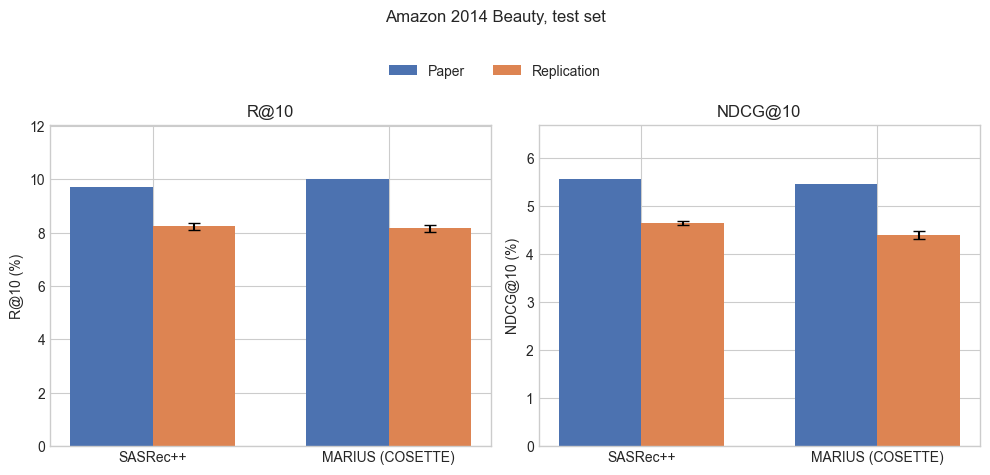

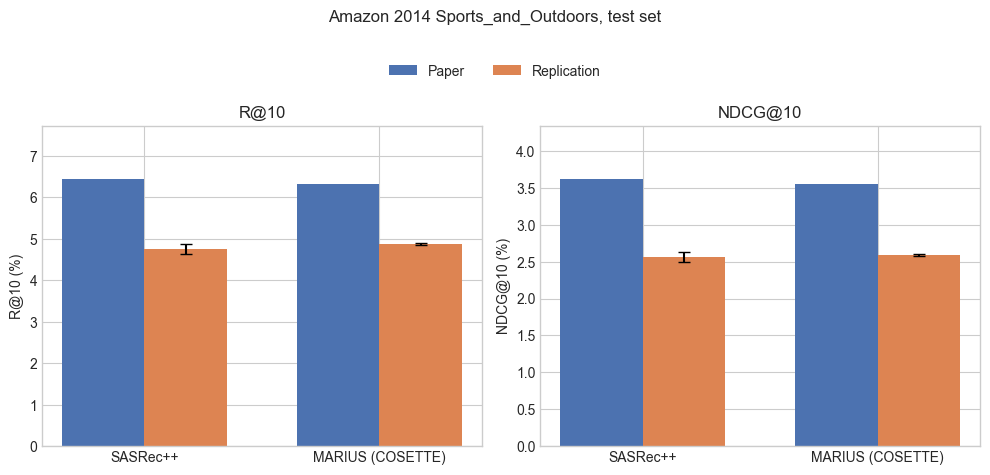

In [6]:
def plot_reported_vs_replicated(category: str) -> None:
    slug = CATEGORIES[category]["slug"]
    plot_metrics = ["R@10", "NDCG@10"]
    methods = [
        ("SASRec++", PAPER_SASREC_PP[category], f"sasrec_{slug}_5seed_full_scores.jsonl"),
        ("MARIUS (COSETTE)", PAPER_MARIUS_COSETTE[category], f"marius_{slug}_5seed_full_scores.jsonl"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=False)
    for ax, metric in zip(axes, plot_metrics):
        labels, reported_vals, replicated_vals, replicated_errs = [], [], [], []
        for label, paper, fname in methods:
            records = load_scores_jsonl(RESULTS_DIR / fname)
            summary = summarize_method(records)
            labels.append(label)
            reported_vals.append(paper[metric][0])
            if summary is None:
                replicated_vals.append(0)
                replicated_errs.append(0)
            else:
                replicated_vals.append(summary[f"{metric}_mean"])
                replicated_errs.append(summary[f"{metric}_std"])

        x = range(len(labels))
        width = 0.35
        ax.bar([i - width / 2 for i in x], reported_vals, width, label="Paper", color="#4C72B0")
        ax.bar(
            [i + width / 2 for i in x],
            replicated_vals,
            width,
            yerr=replicated_errs,
            capsize=4,
            label="Replication",
            color="#DD8452",
        )
        top = max(
            max(reported_vals),
            max(v + e for v, e in zip(replicated_vals, replicated_errs)),
        )
        ax.set_ylim(0, top * 1.2)
        ax.set_xticks(list(x), labels)
        ax.set_ylabel(f"{metric} (%)")
        ax.set_title(metric)

    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2)
    fig.suptitle(f"Amazon 2014 {category}, test set", y=1.12)
    fig.tight_layout()
    plt.show()


for category in CATEGORIES:
    plot_reported_vs_replicated(category)

## 3b. Training dynamics and replication gaps

**Averaged validation curves:** SASRec++ vs MARIUS (COSETTE), mean ± std over five seeds (replicated runs only; the original paper does not publish step-level curves).

Also: test-set **gap** vs reported Table 5, and **seed spread** for replicated runs.

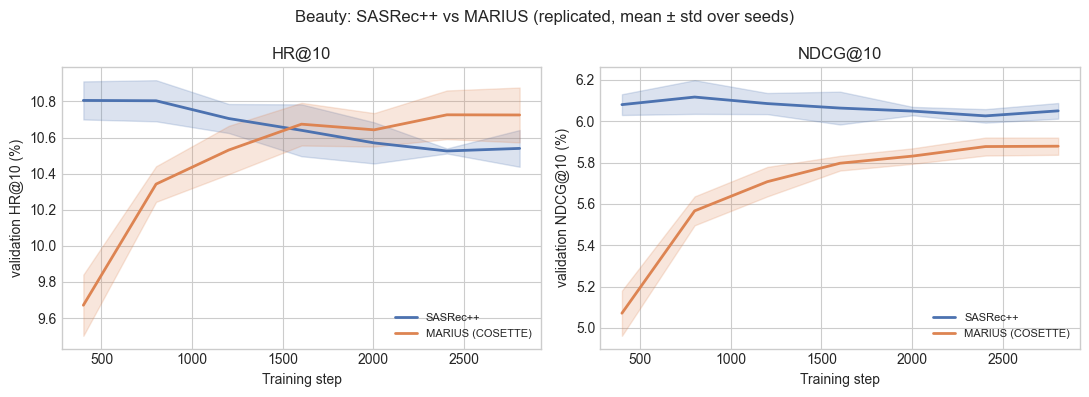

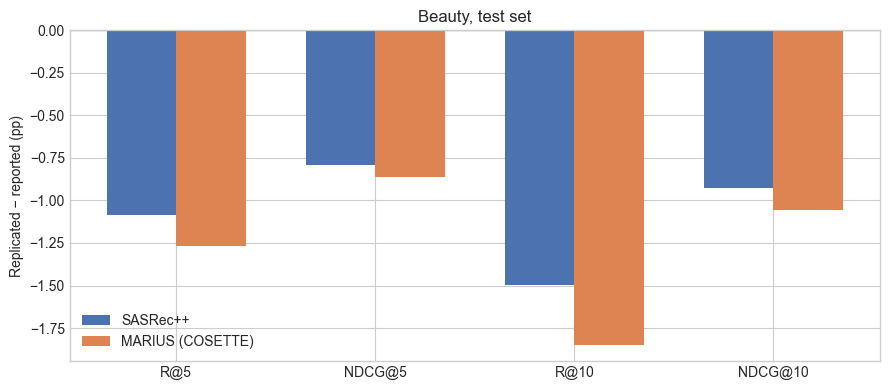

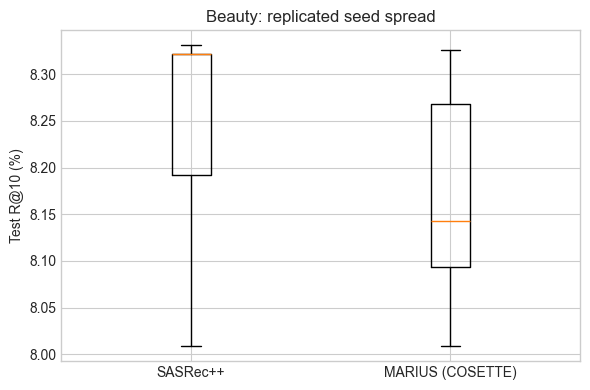

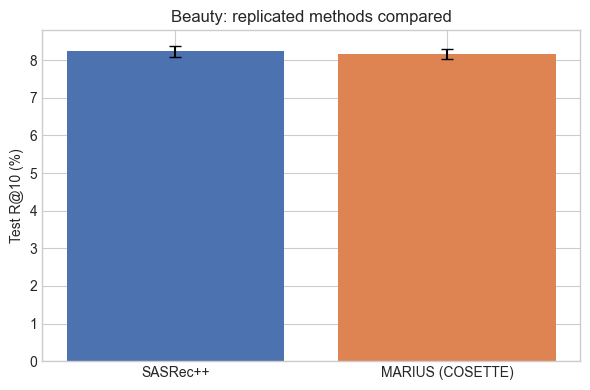

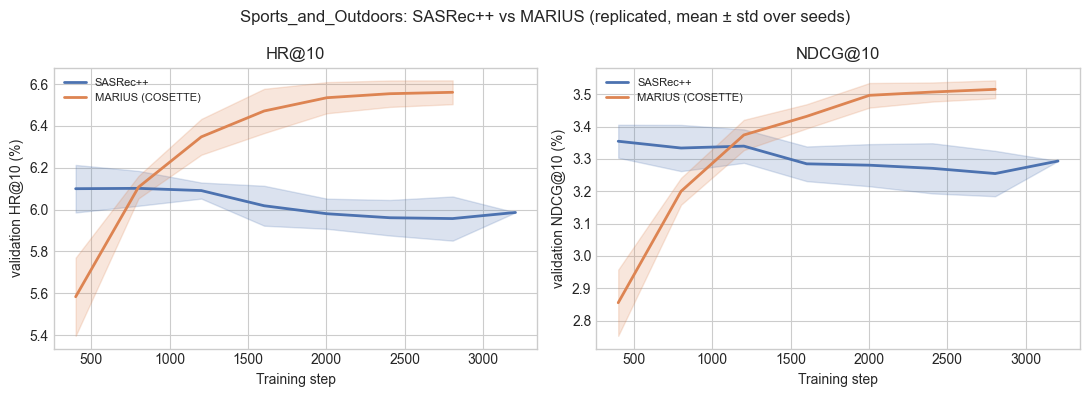

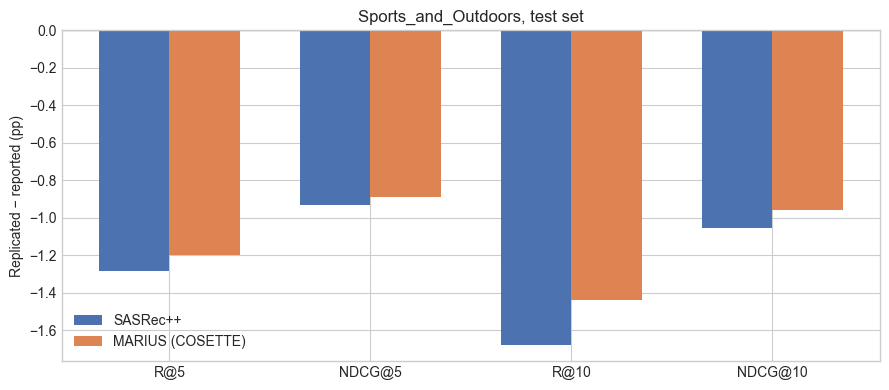

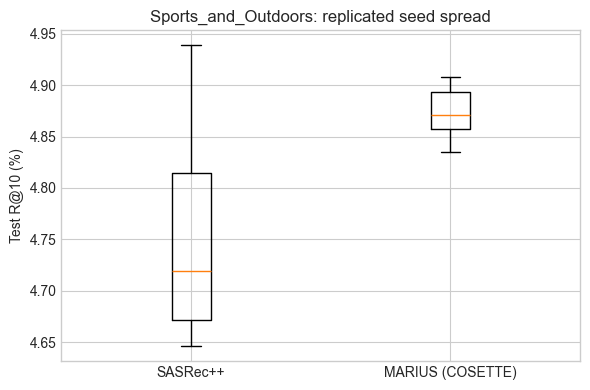

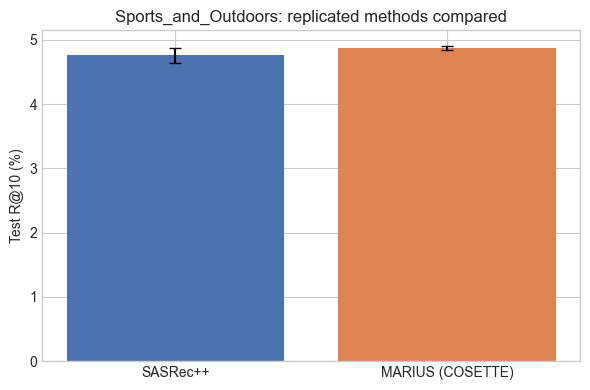

In [7]:
import numpy as np

metrics_df = load_metrics_csvs()


def aggregate_val_curve(
    df: pd.DataFrame,
    *,
    method: str,
    category: str,
    metric: str,
) -> pd.DataFrame | None:
    subset = df[
        (df["method"] == method)
        & (df["category"] == category)
        & (df["metric"] == metric)
    ]
    if subset.empty:
        return None
    wide = subset.pivot_table(index="step", columns="seed", values="value", aggfunc="mean")
    wide = wide.sort_index()
    return pd.DataFrame(
        {
            "step": wide.index.astype(int),
            "mean": wide.mean(axis=1).values,
            "std": wide.std(axis=1).values,
        }
    )


def plot_averaged_sasrec_vs_marius(category: str) -> None:
    if metrics_df.empty:
        print("No metrics CSVs; skip section 3b curves.")
        return

    method_styles = [
        ("sasrec", "SASRec++", "#4C72B0"),
        ("marius", "MARIUS (COSETTE)", "#DD8452"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, metric in zip(axes, ["HR@10", "NDCG@10"]):
        for method_key, label, color in method_styles:
            agg = aggregate_val_curve(metrics_df, method=method_key, category=category, metric=metric)
            if agg is None:
                continue
            y = 100.0 * agg["mean"]
            ystd = 100.0 * agg["std"].fillna(0.0)
            ax.plot(agg["step"], y, label=label, color=color, linewidth=2)
            ax.fill_between(agg["step"], y - ystd, y + ystd, color=color, alpha=0.2)
        ax.set_xlabel("Training step")
        ax.set_ylabel(f"validation {metric} (%)")
        ax.set_title(metric)
        ax.legend(fontsize=8)
    fig.suptitle(f"{category}: SASRec++ vs MARIUS (replicated, mean ± std over seeds)")
    fig.tight_layout()
    plt.show()


def plot_replication_gap(category: str) -> None:
    slug = CATEGORIES[category]["slug"]
    configs = [
        ("SASRec++", PAPER_SASREC_PP[category], f"sasrec_{slug}_5seed_full_scores.jsonl"),
        ("MARIUS (COSETTE)", PAPER_MARIUS_COSETTE[category], f"marius_{slug}_5seed_full_scores.jsonl"),
    ]
    rows = []
    for name, paper, fname in configs:
        summary = summarize_method(load_scores_jsonl(RESULTS_DIR / fname))
        if summary is None:
            continue
        for metric in ["R@5", "R@10", "NDCG@5", "NDCG@10"]:
            rep = summary[f"{metric}_mean"]
            reported = paper[metric][0]
            rows.append(
                {
                    "method": name,
                    "metric": metric,
                    "gap_pp": rep - reported,
                }
            )
    if not rows:
        print(f"No scores for gap plot: {category}")
        return

    gap_df = pd.DataFrame(rows)
    metrics_order = ["R@5", "NDCG@5", "R@10", "NDCG@10"]
    fig, ax = plt.subplots(figsize=(9, 4))
    bar_w = 0.35
    x = np.arange(len(metrics_order))
    for i, (name, color) in enumerate(
        [("SASRec++", "#4C72B0"), ("MARIUS (COSETTE)", "#DD8452")]
    ):
        part = gap_df[gap_df["method"] == name].set_index("metric").reindex(metrics_order)
        ax.bar(x + (i - 0.5) * bar_w, part["gap_pp"], width=bar_w, label=name, color=color)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x, metrics_order)
    ax.set_ylabel("Replicated − reported (pp)")
    ax.set_title(f"{category}, test set")
    ax.legend()
    fig.tight_layout()
    plt.show()


def plot_seed_spread(category: str) -> None:
    slug = CATEGORIES[category]["slug"]
    configs = [
        ("SASRec++", f"sasrec_{slug}_5seed_full_scores.jsonl"),
        ("MARIUS (COSETTE)", f"marius_{slug}_5seed_full_scores.jsonl"),
    ]
    data, labels = [], []
    for name, fname in configs:
        records = load_scores_jsonl(RESULTS_DIR / fname)
        if not records:
            continue
        data.append([float(r["R@10"]) for r in records])
        labels.append(name)
    if not data:
        return

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(data, tick_labels=labels)
    ax.set_ylabel("Test R@10 (%)")
    ax.set_title(f"{category}: replicated seed spread")
    fig.tight_layout()
    plt.show()


def plot_replicated_sasrec_vs_marius(category: str) -> None:
    slug = CATEGORIES[category]["slug"]
    configs = [
        ("SASRec++", f"sasrec_{slug}_5seed_full_scores.jsonl"),
        ("MARIUS (COSETTE)", f"marius_{slug}_5seed_full_scores.jsonl"),
    ]
    fig, ax = plt.subplots(figsize=(6, 4))
    labels, means, stds = [], [], []
    for name, fname in configs:
        summary = summarize_method(load_scores_jsonl(RESULTS_DIR / fname))
        if summary is None:
            continue
        labels.append(name)
        means.append(summary["R@10_mean"])
        stds.append(summary["R@10_std"])
    if not labels:
        return
    x = np.arange(len(labels))
    ax.bar(x, means, yerr=stds, capsize=4, color=["#4C72B0", "#DD8452"][: len(labels)])
    ax.set_xticks(x, labels)
    ax.set_ylabel("Test R@10 (%)")
    ax.set_title(f"{category}: replicated methods compared")
    fig.tight_layout()
    plt.show()


for _category in CATEGORIES:
    plot_averaged_sasrec_vs_marius(_category)
    plot_replication_gap(_category)
    plot_seed_spread(_category)
    plot_replicated_sasrec_vs_marius(_category)

## 4. Learning curves (`reports/metrics/*.csv`)

Validation and training curves are loaded from exported CSV files. Regenerate with:

`python scripts/export_metrics_for_report.py --source wandb`

In [8]:
metrics_df = load_metrics_csvs()
if metrics_df.empty:
    print(
        f"No CSV files in {METRICS_DIR}.\n"
        "Export learning curves with:\n"
        "  python scripts/export_metrics_for_report.py --source wandb\n"
        "Then re-run this notebook."
    )
else:
    print(f"Loaded {len(metrics_df):,} metric rows from {metrics_df['source_file'].nunique()} files.")
    display(metrics_df.head())

Loaded 4,704 metric rows from 22 files.


,method,category,seed,step,metric,value,run_name,run_id,source_file
0,cosette,COSETTE_128d_256x4_8ed1,NaN,0,train_loss,0.063617,COSETTE_128d_256x4_8ed1,4yqz7d4t,cosette_COSETTE_128d_256x4_8ed1.csv
1,cosette,COSETTE_128d_256x4_8ed1,NaN,0,lr,0.000109,COSETTE_128d_256x4_8ed1,4yqz7d4t,cosette_COSETTE_128d_256x4_8ed1.csv
2,cosette,COSETTE_128d_256x4_8ed1,NaN,1,train_loss,0.030261,COSETTE_128d_256x4_8ed1,4yqz7d4t,cosette_COSETTE_128d_256x4_8ed1.csv
3,cosette,COSETTE_128d_256x4_8ed1,NaN,1,lr,0.000118,COSETTE_128d_256x4_8ed1,4yqz7d4t,cosette_COSETTE_128d_256x4_8ed1.csv
4,cosette,COSETTE_128d_256x4_8ed1,NaN,2,train_loss,0.013037,COSETTE_128d_256x4_8ed1,4yqz7d4t,cosette_COSETTE_128d_256x4_8ed1.csv


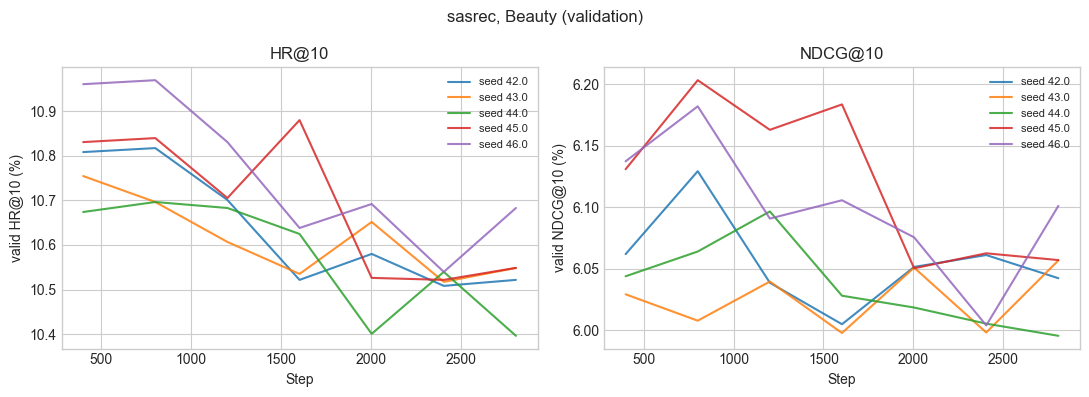

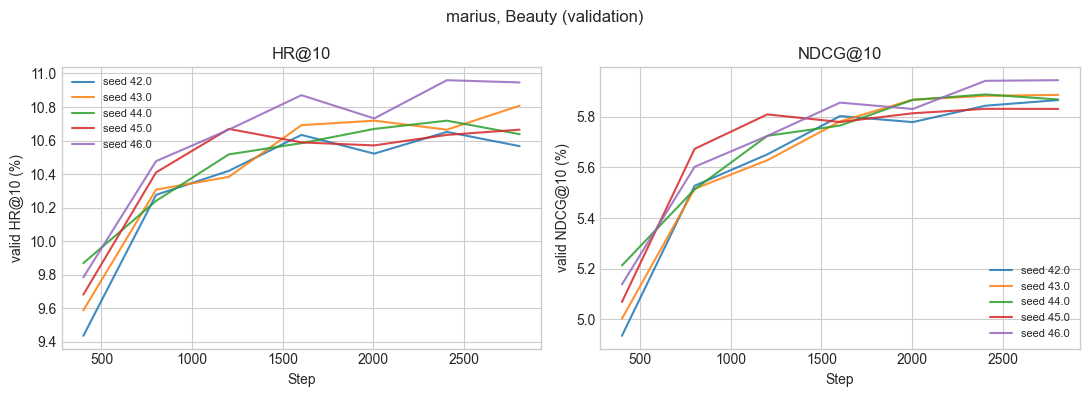

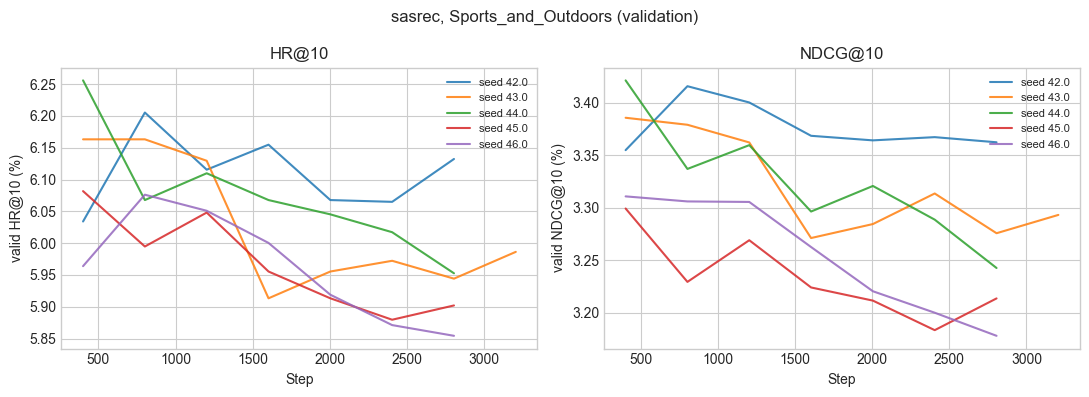

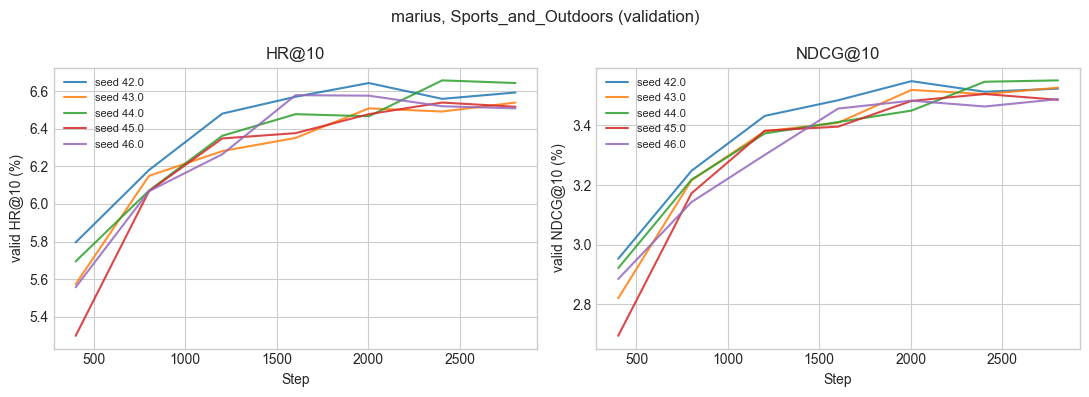

In [9]:
def plot_val_curves(category: str, method: str) -> None:
    if metrics_df.empty:
        return

    subset = metrics_df[
        (metrics_df["method"] == method)
        & (metrics_df["category"] == category)
        & (metrics_df["metric"].isin(["HR@10", "NDCG@10"]))
    ]
    if subset.empty:
        print(f"No validation curves for {method} / {category}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, metric in zip(axes, ["HR@10", "NDCG@10"]):
        for seed, group in subset[subset["metric"] == metric].groupby("seed"):
            group = group.sort_values("step")
            ax.plot(group["step"], 100.0 * group["value"], label=f"seed {seed}", alpha=0.85)
        ax.set_xlabel("Step")
        ax.set_ylabel(f"valid {metric} (%)")
        ax.set_title(metric)
        ax.legend(fontsize=8)
    fig.suptitle(f"{method}, {category} (validation)")
    fig.tight_layout()
    plt.show()


if not metrics_df.empty:
    for category in CATEGORIES:
        plot_val_curves(category, "sasrec")
        plot_val_curves(category, "marius")

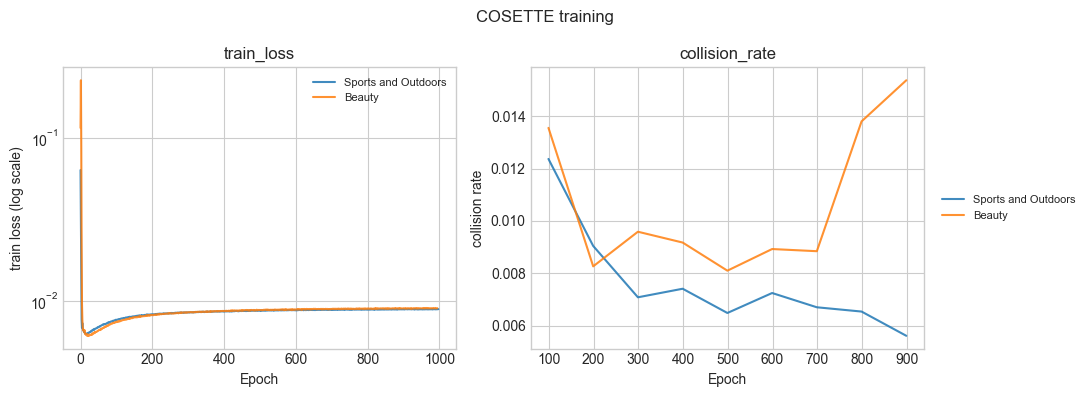

In [10]:
def plot_cosette_curves() -> None:
    if metrics_df.empty:
        return
    subset = metrics_df[
        (metrics_df["method"] == "cosette")
        & (metrics_df["metric"].isin(["train_loss", "collision_rate"]))
    ]
    if subset.empty:
        print("No COSETTE curves exported yet.")
        return

    def cosette_label(run_name: str) -> str:
        for category, quant_id in COSETTE_RUNS.items():
            if run_name.replace("-col", "") in quant_id:
                return category.replace("_", " ")
        return run_name

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    ax = axes[0]
    for run_name, group in subset[subset["metric"] == "train_loss"].groupby("run_name"):
        group = group.sort_values("step")
        ax.semilogy(
            group["step"],
            group["value"].clip(lower=1e-4),
            label=cosette_label(run_name),
            alpha=0.85,
        )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("train loss (log scale)")
    ax.set_title("train_loss")
    ax.legend(fontsize=8, loc="upper right")

    ax = axes[1]
    for run_name, group in subset[subset["metric"] == "collision_rate"].groupby("run_name"):
        group = group.sort_values("step")
        ax.plot(group["step"], group["value"], label=cosette_label(run_name), alpha=0.85)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("collision rate")
    ax.set_title("collision_rate")
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))

    fig.suptitle("COSETTE training")
    fig.tight_layout()
    plt.show()


plot_cosette_curves()

## 5. Methods summary

- **Metrics:** test-split R@K and NDCG@K, aggregated over seeds 42–46 (mean ± std).
- **Artifacts:** final scores in `reports/results/*_scores.jsonl`; curves in `reports/metrics/*.csv`.
- **Training:** SASRec++ baseline; MARIUS with COSETTE tokenization (`experiment=marius_small`, 80k steps, batch size 256, full validation every 10k steps). See `REPRODUCIBILITY.md` for the full pipeline.
- **Reproducibility:** re-run experiments, then `python scripts/export_metrics_for_report.py --copy-results --source wandb` before executing this notebook.